In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          16-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

# De data waarop getraind wordt.
data = pd.read_csv("data_train.csv", sep = ",")


In [2]:
# numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure','Subscription Length','Seconds of Use','Frequency of use','Frequency of SMS']
faccols = ['Age Group','Complaints']
droplevels = [1,0]

# columntransformer voor de datapreperatie fase.
dataprep_SVM = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output = False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep_SVM.set_output(transform = 'pandas')
dataprep_SVM


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [3]:
# De churn wordt uit de traindata gelaten.
X = data.drop(columns = ['Churn'])
Y = data["Churn"]
print(sum(Y))

# Het splitsen van de data wordt hier gedaan.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1987)
print(sum(Y))
print(sum(Y_test))

# Het model wordt meegegeven aan de pipeline om eventueel gebruikt te kunnen worden in de evaluation en deployment.
model_SVM = Pipeline([('preprocessing', dataprep_SVM),
                    ('modelSVM', SVC(
                    kernel = 'poly',
                    coef0 = 1,
                    probability = True,
                    degree = 2,
                    C = 0.01,
                    gamma = 0.01))])
model_SVM.fit(X_train, Y_train)


316
316
91


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('modelSVM', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [4]:
model = SVC()
model.fit(X_train, Y_train)

predictions = model.predict(X_test)
print(classification_report(Y_test, predictions))
predictions


              precision    recall  f1-score   support

           0       0.85      1.00      0.92       508
           1       0.00      0.00      0.00        91

    accuracy                           0.85       599
   macro avg       0.42      0.50      0.46       599
weighted avg       0.72      0.85      0.78       599



c:\Users\jeffr\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jeffr\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jeffr\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [5]:
# Wij slaan de pipeline op als een pickle bestand.
with open('pipelineSVM.pkl', 'wb') as file:
    pickle.dump(model_SVM, file)


In [6]:
gridsearch = GridSearchCV(
    estimator = SVC(kernel='poly', coef0=1, probability=True), 
    param_grid = [{'degree':np.arange(2,15)}],
    scoring = 'accuracy',
    verbose=2).fit(X_train, Y_train)

gridsearch.best_estimator_
predicted = gridsearch.predict(X_test)
predicted


Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV] END ...........................................degree=2; total time=   0.1s
[CV] END ...........................................degree=2; total time=   0.0s
[CV] END ...........................................degree=2; total time=   0.1s
[CV] END ...........................................degree=2; total time=   0.1s
[CV] END ...........................................degree=2; total time=   0.0s
[CV] END ...........................................degree=3; total time=   0.1s
[CV] END ...........................................degree=3; total time=   0.1s
[CV] END ...........................................degree=3; total time=   0.2s
[CV] END ...........................................degree=3; total time=   0.1s
[CV] END ...........................................degree=3; total time=   0.0s
[CV] END ...........................................degree=4; total time=   0.1s
[CV] END .......................................

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [7]:
# Gridsearch voor Support Vector Machine met willekeurig gekozen waarden.
gridsearch_SVM = GridSearchCV(
    estimator = SVC(probability = True, coef0 = 1, kernel = 'poly'),
    refit = False,
    param_grid = {
        'degree': np.arange(2, 15),
        'C': [0.01, 0.1, 1, 10], 
        'gamma': [0.01, 0.1, 1, 10]},
    scoring = ["accuracy", "precision"],
    verbose = 2).fit(X_train, Y_train)

# Na de gridsearch met deze parameters laten zien welke combinatie het beste is.
gridsearch_SVM.best_estimator_


Fitting 5 folds for each of 208 candidates, totalling 1040 fits


: 

: 

In [ ]:
# Gridsearch voor Support Vector Machine met C-waarden gekozen die dicht tegen C-waarde van 10 zitten.
gridsearch_SVM = GridSearchCV(
    estimator = SVC(probability = True, coef0 = 1, kernel = 'poly'), 
    param_grid = {
        'degree': np.arange(2, 15),
        'C': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 
        'gamma': [0.01, 0.1, 1, 10]},
    scoring = 'F1-score',
    verbose = 2).fit(X_train, Y_train)

# Na de gridsearch met deze parameters laten zien welke combinatie het beste is.
gridsearch_SVM.best_estimator_


Fitting 5 folds for each of 520 candidates, totalling 2600 fits
[CV] END ..........................C=5, degree=2, gamma=0.01; total time=   0.4s
[CV] END ..........................C=5, degree=2, gamma=0.01; total time=   0.4s
[CV] END ..........................C=5, degree=2, gamma=0.01; total time=   0.4s
[CV] END ..........................C=5, degree=2, gamma=0.01; total time=   0.4s
[CV] END ..........................C=5, degree=2, gamma=0.01; total time=   0.4s
[CV] END ...........................C=5, degree=2, gamma=0.1; total time=   0.4s
[CV] END ...........................C=5, degree=2, gamma=0.1; total time=   0.4s
[CV] END ...........................C=5, degree=2, gamma=0.1; total time=   0.4s
[CV] END ...........................C=5, degree=2, gamma=0.1; total time=   0.4s
[CV] END ...........................C=5, degree=2, gamma=0.1; total time=   0.4s
[CV] END .............................C=5, degree=2, gamma=1; total time=   0.4s
[CV] END .............................C=5, de

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",12
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",np.int64(2)
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# Uit de gridsearch zijn deze parameters als de beste samenstelling gekomen en daarom dienen zij hier aangepast te worden.
model_SVM.C = 1
model_SVM.gamma = 0.01
model_SVM.degree = 2


In [ ]:
# Hier wordt het voorspellen op de validatiedata gedaan.
predicted = model_SVM.predict(X_test)


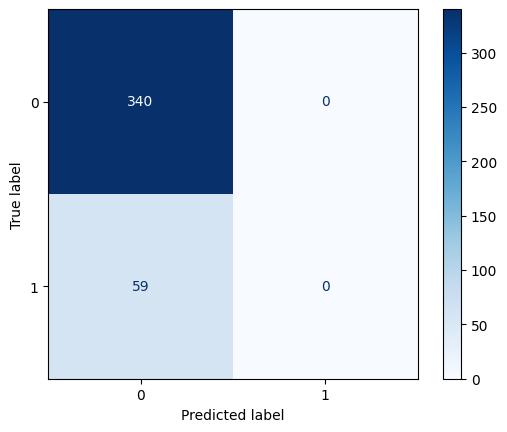

In [ ]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test, predicted, cmap = 'Blues')
plt.show()


In [ ]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(Y_test, predicted), 2)
rec = round(recall_score(Y_test, predicted), 2)
pre = round(precision_score(Y_test, predicted), 2)
fsco = round(f1_score(Y_test, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df
print("Het aantal support vectors die zijn gebruikt is: ", len(model_SVM.support_), sep = "")


c:\Users\jeffr\anaconda3\envs\BP3.4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Name,Value
0,Accuracy,0.85
1,Recall,0.00
2,Precision,0.00
3,F1-score,0.00


TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.

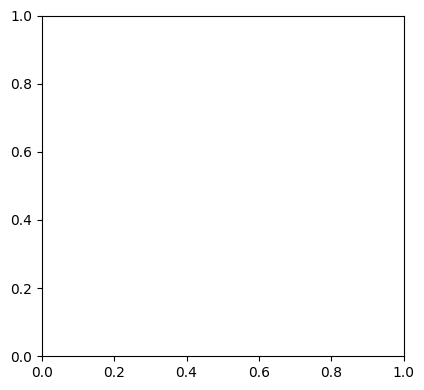

In [ ]:
# We definieren hier een functie voor het maken van een pairplot bestaande uit een verdeling voorspelde kansen, een metric plot en een ROC curve.
def make_row(cr):
    return{
        'Accuracy': cr['accuracy'],
        'Recall': cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 score': cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        Y_test,
        predicted[:] > t,
        zero_division = True,
        output_dict = True
    )) for t in thresholds
])
plot_data.index = thresholds

plt.figure(figsize = (12, 4), layout = 'tight')

# Verdeling van de voorspelde kansen.
plt.subplot(1, 3, 1)
sns.kdeplot(data = Y_train, x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('verdeling voorspelde kansen')

# Metric plot
nul_acc = accuracy_score(Y_train, 0)
plt.subplot(1, 3, 2)
sns.lineplot(plot_data)
plt.plot([0,1], [nul_acc, nul_acc], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    Y_train,
    predicted[:],
    name = '',
    plot_chance_level = True,
    ax = ax
)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()
